In [172]:
import os
import time
try: import uncertainties
except: os.system("pip install uncertainties")

In [173]:
from uncertainties import ufloat
from uncertainties import unumpy as unp
import numpy as np
import matplotlib.pyplot as plt
import scipy.optimize as opt
from scipy.optimize import curve_fit
import pandas as pd


def pr(obj,label=None, split = False):
  if callable(obj):
    def new_func(*args,**kwargs):
      result=obj(*args,**kwargs)
      if label: print(label.format(*result)) if split else print(label.format(result))
      else:
        if split:
          for r in result: print(r)
        else: print(result)
      return result
    return new_func

  else:
    if label: print(label.format(*obj)) if split else print(label.format(obj))
    else:
      if split:
        for r in obj: print(r)
      else: print(obj)
    return obj


agree = lambda x,y: (np.abs(x.n-y.n) <= np.sqrt(np.square(x.s)+np.square(y.s)))
v_err = lambda v: 0.013*np.abs(v) + 0.008*(10**np.floor(np.log10(v)))
a_err = lambda a: 0.015*np.abs(a) + 0.008*(10**np.floor(np.log10(a)))
r_err = lambda r: 0.01*np.abs(r) + 0.005*(10**np.floor(np.log10(r))) if r!=0 else 0.005
c_err = lambda f: 0.04*np.abs(f) + 0.05*(10**np.floor(np.log10(f))) if f!=0 else 0.5

@np.vectorize
def u_convert(arr,err_fn):
  if callable(err_fn):
    return ufloat(arr,err_fn(arr))
  else: return ufloat(arr,err_fn)

def compare(a,b, prefix="", labels = ("Predicted: {:.3e}","Measured: {:.3e}","agree: {}"), ):
  print(" | ".join((prefix,)+labels).format(a,b,agree(a,b)))

pi = np.pi
sqrt = np.sqrt
sin = np.sin
cos = np.cos
tan = np.tan
ln = np.log
log = np.log10
square = np.square
exp = np.exp

u = ufloat
u_c = u_convert
r_c = lambda x: u_convert(x,r_err)
nom = unp.nominal_values
std = unp.std_devs

In [174]:
from lab_10_template import *
print(
    ADSHardware,
    fft
)


<class 'lab_10_template.ADSHardware'> <function fft at 0x000002222ABD77E0>


In [4]:
ads = None
ads = ADSHardware()
try: ads.disconnect()
except: pass
ads.startup()

## 10.1

In [5]:
ads.use_wavegen(amp_v = 2, freq_hz = 1)
#time.sleep(5)
ads.use_wavegen(amp_v = 2, freq_hz = 10)
#time.sleep(10)
ads.use_wavegen(amp_v = 2, freq_hz = 100)

In [6]:
ads.use_wavegen(amp_v = 2.0, freq_hz = 50)

In [7]:
ads.close_wavegen()

## 10.2

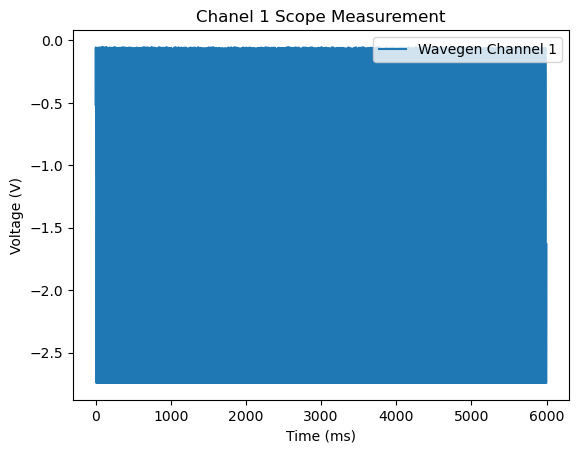

In [8]:
#d)

ads.use_wavegen(offset_v = 2.75, amp_v = 1, freq_hz = 50)

data_102 = oscilloscope_run(ads, duration=6, channel=1)

plt.plot(data_102["x"], data_102["y"], label="Wavegen Channel 1")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.title("Chanel 1 Scope Measurement")
plt.legend(loc = "upper right")

#plt.savefig("10.2b.png")
#plt.savefig("10.2d.png")
plt.show()


ads.close_wavegen()


## 10.3

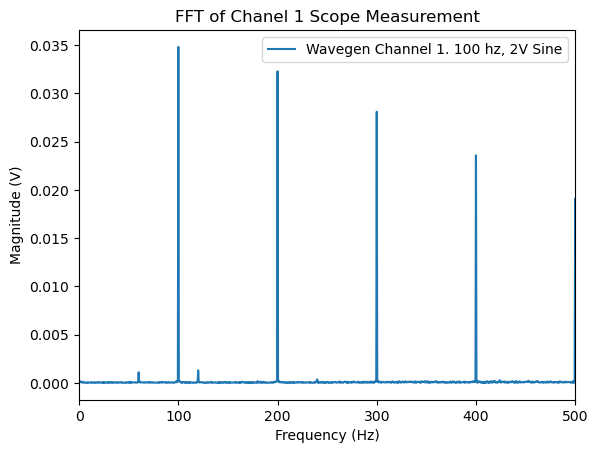

In [ ]:
#a)

ads.use_wavegen(amp_v = 2, freq_hz = 100)
data_103 = oscilloscope_run(ads, 2, 1, 2000)
ads.close_wavegen()

fft_103 = fft(data_103)
fft_103_pos = {key: val[fft_103["frequencies"] > 0] for key, val in fft_103.items()}

plt.plot(fft_103_pos["frequencies"], fft_103_pos["magnitudes"], label="Wavegen Channel 1. 100 hz, 2V Sine")
plt.xlabel("Frequency (Hz)")
plt.xlim(0,500)
plt.ylabel("Magnitude (V)")
plt.title("FFT of Chanel 1 Scope Measurement")
plt.legend(loc = "upper right")
plt.show()


## 10.5

In [39]:
ads.close_wavegen()

ads.use_wavegen(offset_v = 2.75, amp_v = 1, freq_hz = 50)
#ads.use_wavegen(channel=1, function=wavegen_functions["dc"],offset_v=2.75)

time.sleep(2) #so everything can 'settle' before data is collected

raw_data = oscilloscope_run(ads, duration=10, channel=1, sampling_freq=500)

ads.close_wavegen()

In [ ]:
#save_data = np.loadtxt("heartbeat_data/DC_baseband_raw10.txt", delimiter=" ")
#raw_data = {"x": save_data[0, :], "y": save_data[1,:]}

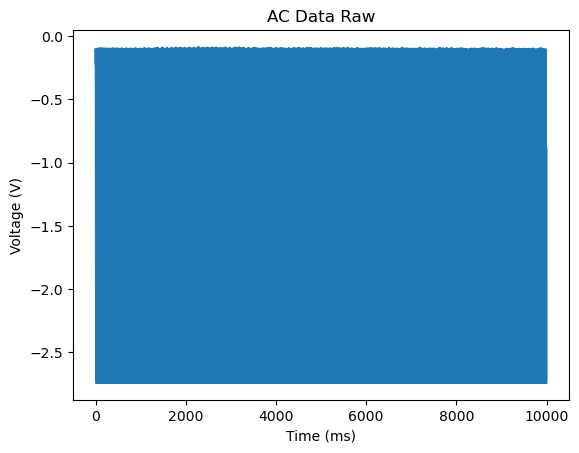

Main Frequency: 150.00 Hz bpm is  9000.0


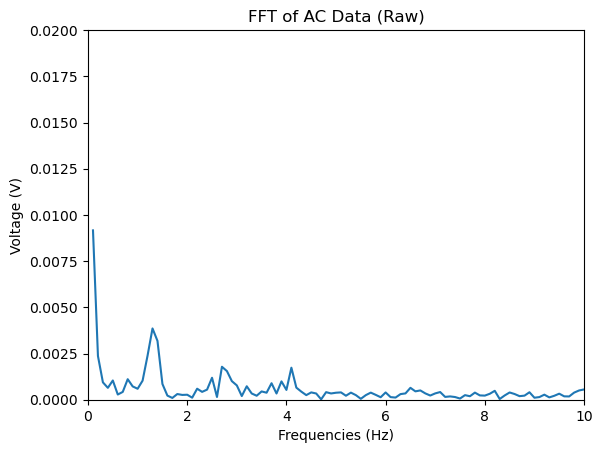

In [41]:
plt.plot(raw_data["x"], raw_data["y"])
#plt.grid(visible=True, which='major', color='black', linestyle='-')
#plt.grid(visible=True, which='minor', color='black', linestyle='--')
plt.xlabel('Time (ms)')
plt.ylabel('Voltage (V)')
plt.title("AC Data Raw")
plt.show()

#fname = os.path.join('./heartbeat_data', 'demod_lockin'+time.strftime("%Y%m%d-%H%M%S")+".txt")
#np.savetxt(fname, np.array([raw_data["x"], raw_data["y"]]))

fft_raw = fft(raw_data)
maxf = fft_raw["frequencies"][np.argsort(fft_raw["magnitudes"])[-2]]
print("Main Frequency: {:.2f} Hz".format(maxf), "bpm is ", maxf * 60)


plt.plot(fft_raw["frequencies"], fft_raw["magnitudes"])
plt.xlabel("Frequencies (Hz)")
plt.ylabel("Voltage (V)")
plt.xlim(0,10)
plt.ylim(0,0.02)
#plt.grid(visible=True, which='major', color='black', linestyle='-')
#plt.grid(visible=True, which='minor', color='black', linestyle='--')
plt.title("FFT of AC Data (Raw)")
plt.show()

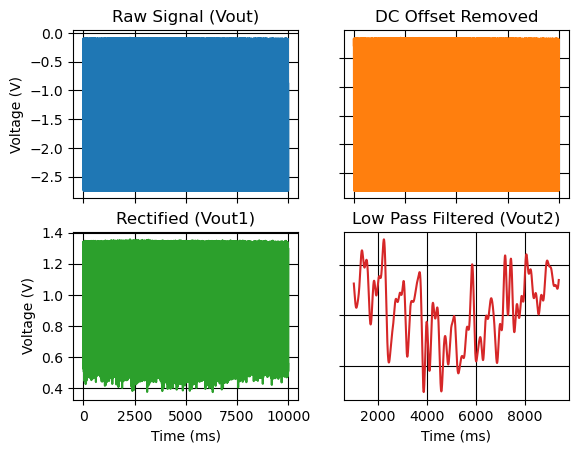

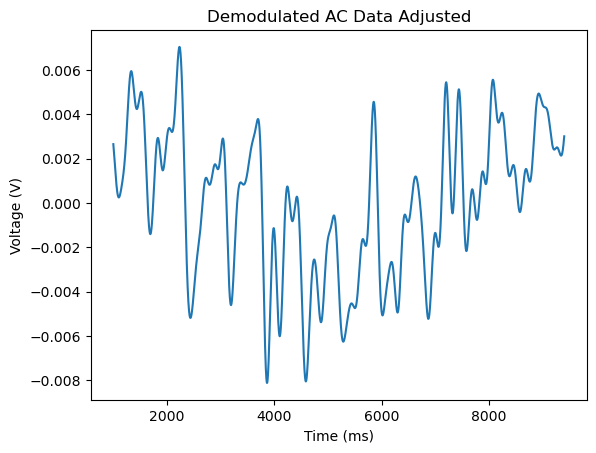

Main Frequency: 1.31 Hz bpm is  78.57142857142853


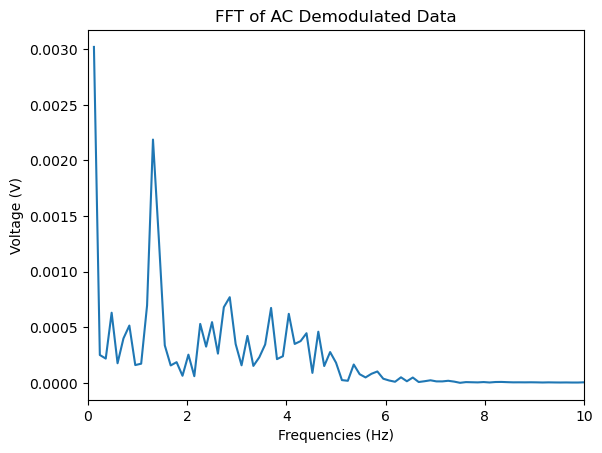

In [136]:
demod_data_radio = demodulate_radio(raw_data, 5, save = True)
#demod_data_radio = {key:item[100:-100] for key, item in demod_data_radio.items()}
demod_data_radio['y'] = demod_data_radio['y'] - np.mean(demod_data_radio['y'])
plt.plot(demod_data_radio["x"], demod_data_radio["y"])
plt.title("Demodulated AC Data Adjusted")
plt.xlabel("Time (ms)")
plt.ylabel("Voltage (V)")
plt.show()

fft_data_105 = fft(demod_data_radio)
maxf = fft_data_105["frequencies"][np.argsort(fft_data_105["magnitudes"])[-2]]
print("Main Frequency: {:.2f} Hz".format(maxf), "bpm is ", maxf * 60)

plt.plot(fft_data_105["frequencies"], fft_data_105["magnitudes"])
plt.xlabel("Frequencies (Hz)")
plt.xlim(0,10)
plt.ylabel("Voltage (V)")
#plt.grid(visible=True, which='major', color='black', linestyle='-')
#plt.grid(visible=True, which='minor', color='black', linestyle='--')
plt.title("FFT of AC Demodulated Data")
plt.show()

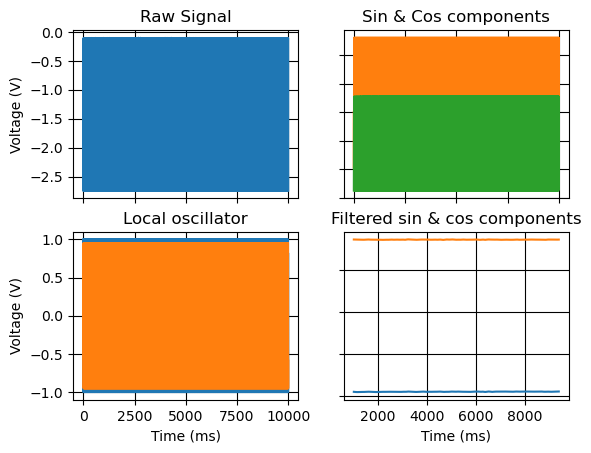

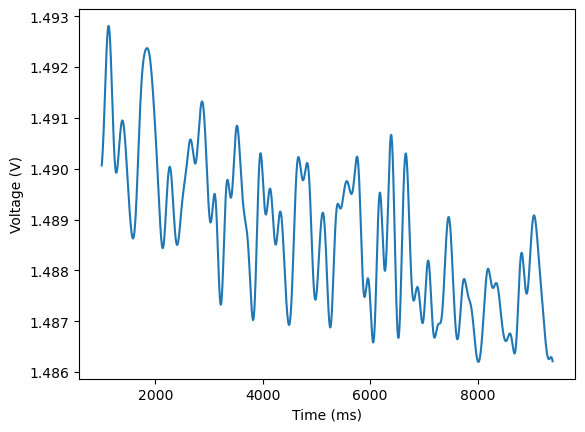

In [131]:
### DEMOD LOCKIN
# UNCOMMENT THE LINE BELOW FOR L10.6(b)
demod_data_lockin = demodulate_lockin(ads, duration=10, nu_mod=50, nu_3db=5)

In [184]:
### APPROACH COMPARISON

#if you want to use data from a different run, uncomment the following lines
dc_baseband_data = {}
demod_data_radio = {}
demod_data_lockin = {}

dc_baseband_data["x"], dc_baseband_data["y"] = np.loadtxt("./heartbeat_data/DC_baseband_raw10.txt")
demod_data_radio["x"], demod_data_radio["y"] = np.loadtxt("./heartbeat_data/demodRadioAC10.txt")
demod_data_lockin["x"], demod_data_lockin["y"] = np.loadtxt("./heartbeat_data/demodLockin1.txt")

dc_baseband_data["y"], dc_baseband_data["x"] = dc_baseband_data["y"][500:-300], dc_baseband_data["x"][500:-300]

Main Frequency: 3.82 Hz bpm is  229.41176470588223


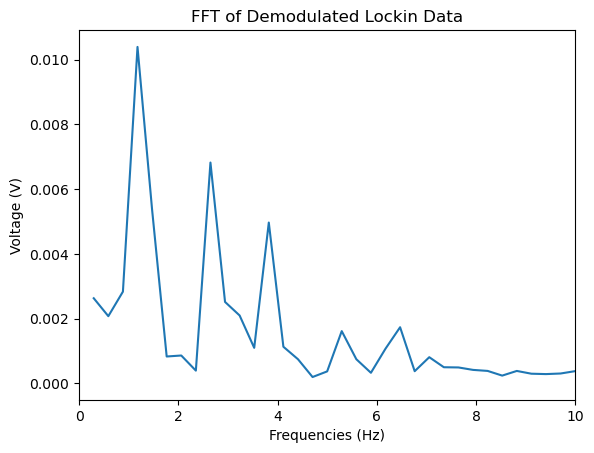

In [185]:
fft_data_lockin = fft(demod_data_lockin)

maxf = fft_data_lockin["frequencies"][np.argsort(fft_data_lockin["magnitudes"])[-4]]
print("Main Frequency: {:.2f} Hz".format(maxf), "bpm is ", maxf * 60)

plt.plot(fft_data_lockin["frequencies"], fft_data_lockin["magnitudes"])
plt.xlabel("Frequencies (Hz)")
plt.xlim(0,10)
plt.ylabel("Voltage (V)")
#plt.grid(visible=True, which='major', color='black', linestyle='-')
#plt.grid(visible=True, which='minor', color='black', linestyle='--')
plt.title("FFT of Demodulated Lockin Data")
plt.show()

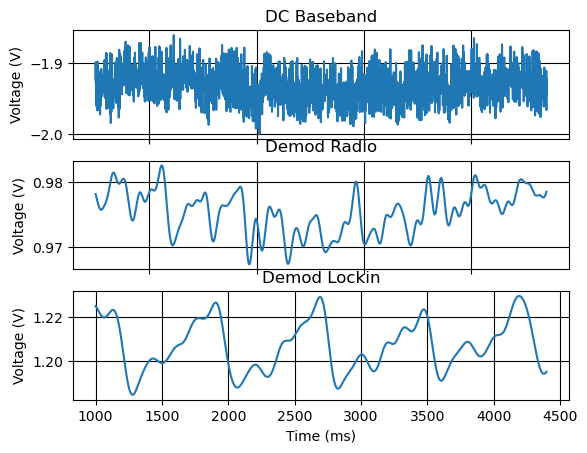

In [186]:
# UNCOMMENT THE CODE BELOW FOR L10.6(c)
fig, axs = plt.subplots(3, 1)
axs[0].plot(dc_baseband_data["x"], dc_baseband_data["y"])
axs[0].set_title("DC Baseband")
axs[1].plot(demod_data_radio["x"], demod_data_radio["y"])
axs[1].set_title("Demod Radio")
axs[2].plot(demod_data_lockin["x"], demod_data_lockin["y"])
axs[2].set_title("Demod Lockin")

for ax in axs.flat:
    ax.set(xlabel='Time (ms)', ylabel='Voltage (V)')
    ax.grid(visible=True, which='major', color='black', linestyle='-')
    ax.grid(visible=True, which='minor', color='black', linestyle='--')

for ax in axs.flat:
    ax.label_outer()

plt.show()

Main Frequency: 1.07 Hz bpm is  64.28571428571426
Main Frequency: 1.31 Hz bpm is  78.57142857142853
Main Frequency: 1.47 Hz bpm is  88.23529411764702


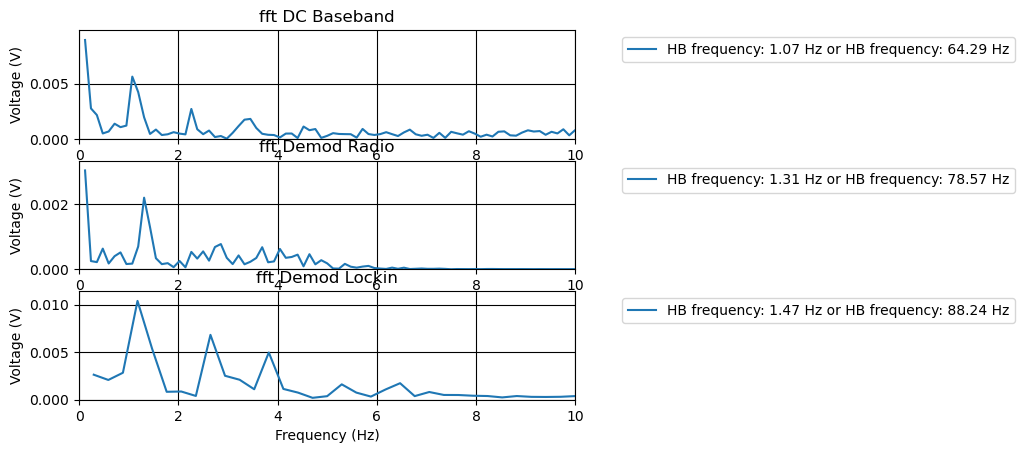

In [187]:
#TODO: FFT COMPARISON
axs = [plt.subplot(3,1,i+1) for i in range(3)]
for i, ds in enumerate((dc_baseband_data, demod_data_radio, demod_data_lockin)):
    fft_ds = fft(ds)

    maxf = fft_ds["frequencies"][np.argsort(fft_ds["magnitudes"])[-2 if i<2 else -3]]
    print("Main Frequency: {:.2f} Hz".format(maxf), "bpm is ", maxf * 60)

    axs[i].plot(fft_ds["frequencies"], fft_ds["magnitudes"], label = "HB frequency: {:.2f} Hz".format(maxf) + " or " + "HB frequency: {:.2f} Hz".format(60*maxf))
    axs[i].set_title(["fft DC Baseband", "fft Demod Radio", "fft Demod Lockin"][i])
    axs[i].set(xlabel='Frequency (Hz)', ylabel='Voltage (V)')
    axs[i].grid(visible=True, which='major', color='black', linestyle='-')
    axs[i].grid(visible=True, which='minor', color='black', linestyle='--')
    axs[i].set_xlim(0,10)
    axs[i].set_ylim([0, max(fft_ds["magnitudes"])*1.1])
    axs[i].legend(loc = "upper right", bbox_to_anchor=(1.9, 1))

    
plt.show()

#TODO: Clipping in Demod Radio

